# White vs. Pink Initial Noise — Sampling & Spectrum Intuition

Companion notebook for the "Noise Optimization for Image Diversity and Quality" slide.
It reproduces the white/pink noise construction from `training/noise_utils.py`
(`z_pink = Normalize(IFFT2D(FFT2D(z_white) / (1+f)^alpha))`) and visualizes:

1. **Sampling**: pink noise is the *same* white-noise draw, only its Fourier spectrum is
   reweighted — not an independent resample.
2. **Spatial appearance**: fine-grained "static" (white) turns into smooth, cloud-like
   blobs (pink) as alpha increases.
3. **Spectrum**: flat power spectral density (white) turns into power concentrated at
   low frequencies, following ~$1/f^{alpha}$ (pink).

Note: latent channels are shown directly as pseudo-RGB for visual intuition; these are
raw noise tensors, not VAE-decoded images.

In [1]:
import numpy as np
import torch
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

SEED = 42
H, W = 128, 128
ALPHAS = [0.0, 0.2, 0.5, 1.0]  # 0 = white noise; matches optimization.noise_exponent in config.py


def sample_white_noise(batch, channels, height, width, seed):
    """Per-sample CPU-seeded white noise (mirrors the repo's white-noise convention)."""
    samples = []
    for i in range(batch):
        gen = torch.Generator(device="cpu").manual_seed(seed + i)
        # z_white: the raw i.i.d. Gaussian noise table before any spectral shaping.
        samples.append(torch.randn(1, channels, height, width, generator=gen))
    return torch.cat(samples, dim=0)


def filter_to_pink(white_noise, alpha):
    """z_pink = Normalize(IFFT2D(FFT2D(z_white) / (1+f)^alpha)).

    Mirrors `training/noise_utils.py::_generate_2d_pink_noise` exactly, so alpha=0.0
    recovers (normalized) white noise and larger alpha emphasizes low frequencies.
    """
    batch, channels, height, width = white_noise.shape
    output = white_noise.clone()
    if alpha != 0.0:
        # f: radial spatial frequency at each FFT bin (0 at DC, larger toward high frequency).
        freq_h = torch.fft.fftfreq(height).view(height, 1) * height
        freq_w = torch.fft.rfftfreq(width).view(1, width // 2 + 1) * width
        # 1/(1+f)^alpha: the higher f is, the more this divides down -> high frequencies get suppressed.
        scaling = 1.0 / (1.0 + torch.sqrt(freq_h**2 + freq_w**2)) ** alpha
        for b in range(batch):
            for c in range(channels):
                # FFT2D: move z_white from spatial layout to frequency-domain coefficients.
                spectrum = torch.fft.rfft2(output[b, c])
                # Apply the reweighting, then IFFT2D: bring the shaped spectrum back to image-shaped noise.
                output[b, c] = torch.fft.irfft2(spectrum * scaling, s=(height, width))

    # Normalize: rescale to zero mean / unit std so the result stays a valid input for the model.
    flat = output.reshape(batch * channels, height * width)
    flat = (flat - flat.mean(1, keepdim=True)) / (flat.std(1, keepdim=True) + 1e-8)
    return flat.reshape_as(output)


# Same base white-noise draw filtered at every alpha: isolates the effect of the
# spectral reweighting from the randomness of the draw itself.
base_white = sample_white_noise(batch=1, channels=3, height=H, width=W, seed=SEED)
noise_by_alpha = {alpha: filter_to_pink(base_white, alpha) for alpha in ALPHAS}

## 1. Spatial appearance: same draw, different spectral filter

`noise_by_alpha` was built from a single `base_white` draw. Each column below only
differs in the alpha used to reweight its Fourier spectrum.

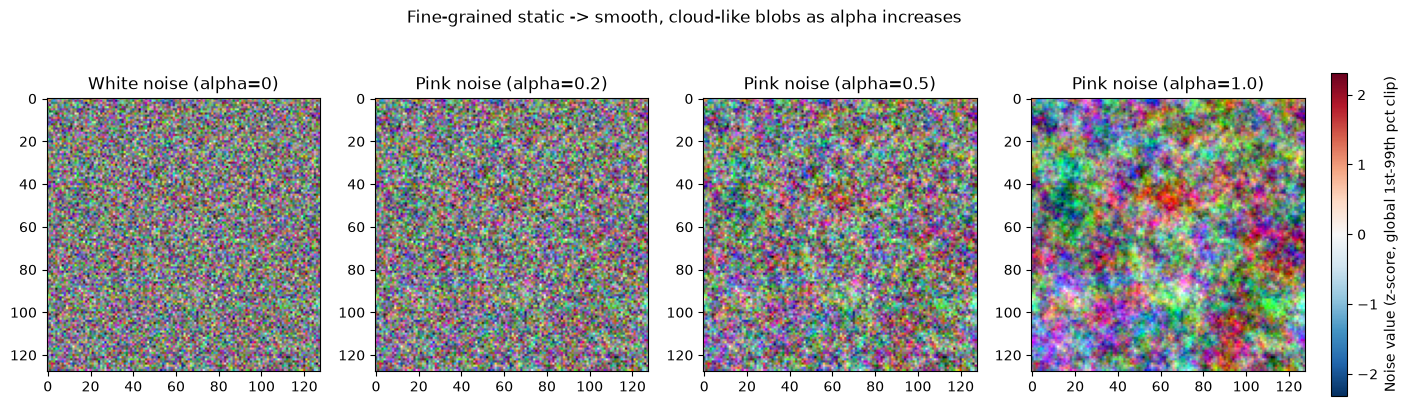

In [2]:
def to_rgb_display(tensor_chw, lo, hi):
    """Clip the first 3 channels to a shared [lo, hi] range and rescale to [0, 1]."""
    img = tensor_chw[:3].detach().numpy().transpose(1, 2, 0)
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)


# Shared clip range across all alphas, so the panels (and their colorbar) stay comparable.
all_raw = np.stack([noise_by_alpha[a][0, :3].numpy() for a in ALPHAS])
raw_lo, raw_hi = np.percentile(all_raw, 1), np.percentile(all_raw, 99)

fig, axes = plt.subplots(1, len(ALPHAS), figsize=(4 * len(ALPHAS) + 1, 4.2))
for ax, alpha in zip(axes, ALPHAS):
    ax.imshow(to_rgb_display(noise_by_alpha[alpha][0], raw_lo, raw_hi))
    ax.set_title("White noise (alpha=0)" if alpha == 0.0 else f"Pink noise (alpha={alpha})")
    ax.set_xticks(range(0, W + 1, 20))
    ax.set_yticks(range(0, H + 1, 20))
# Diverging colormap centered at 0, since the noise is zero-mean/unit-std z-scored.
spatial_norm = mcolors.TwoSlopeNorm(vmin=raw_lo, vcenter=0.0, vmax=raw_hi)
sm = plt.cm.ScalarMappable(norm=spatial_norm, cmap="RdBu_r")
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label="Noise value (z-score, global 1st-99th pct clip)")
fig.suptitle("Fine-grained static -> smooth, cloud-like blobs as alpha increases", y=1.03)
plt.show()

## 2. Frequency-domain view: energy concentrates at low frequencies

2D log-magnitude spectrum (DC/low frequencies at the center after `fftshift`).

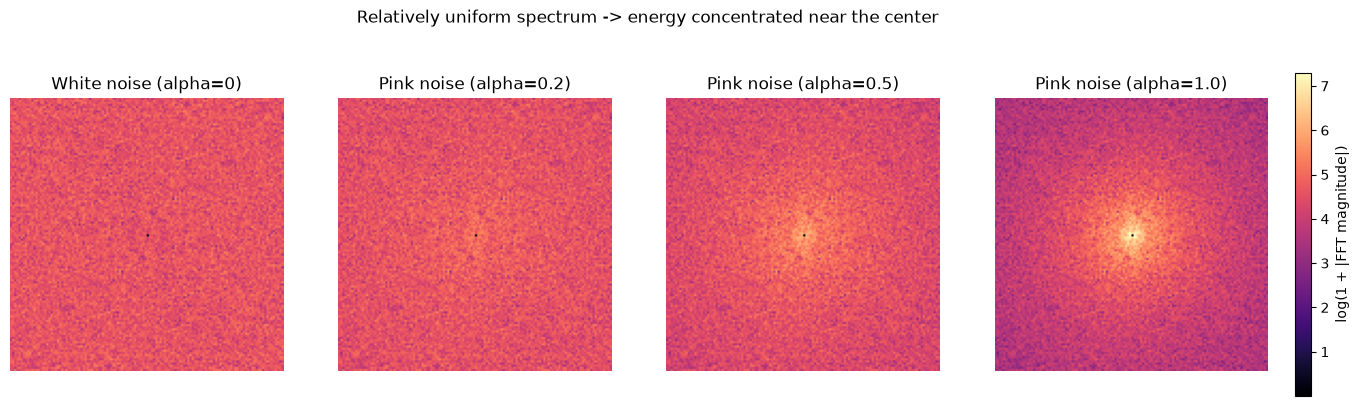

In [3]:
def log_magnitude_spectrum(tensor_chw):
    """Channel-averaged log-magnitude 2D spectrum, shifted so DC is centered."""
    mags = [
        # remember to conduct fftshift -> DC component is centered in the output(low-freq in the middle)
        np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(tensor_chw[c].numpy()))))
        for c in range(tensor_chw.shape[0])
    ]
    return np.mean(mags, axis=0)


spectra = [log_magnitude_spectrum(noise_by_alpha[alpha][0]) for alpha in ALPHAS]
vmin = min(s.min() for s in spectra)
vmax = max(s.max() for s in spectra)  # shared scale so one colorbar is valid for every panel

fig, axes = plt.subplots(1, len(ALPHAS), figsize=(4 * len(ALPHAS) + 1, 4.2))
for ax, alpha, spectrum in zip(axes, ALPHAS, spectra):
    im = ax.imshow(spectrum, cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title("White noise (alpha=0)" if alpha == 0.0 else f"Pink noise (alpha={alpha})")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="log(1 + |FFT magnitude|)")
fig.suptitle("Relatively uniform spectrum -> energy concentrated near the center", y=1.03)
plt.show()

## 3. Radially-averaged power spectral density (quantitative view)

White noise has a flat PSD; pink noise follows the `1/(1+f)^(2*alpha)` power-law used
to build it, giving a direct numerical readout of the "low-frequency emphasis" shown
qualitatively above.

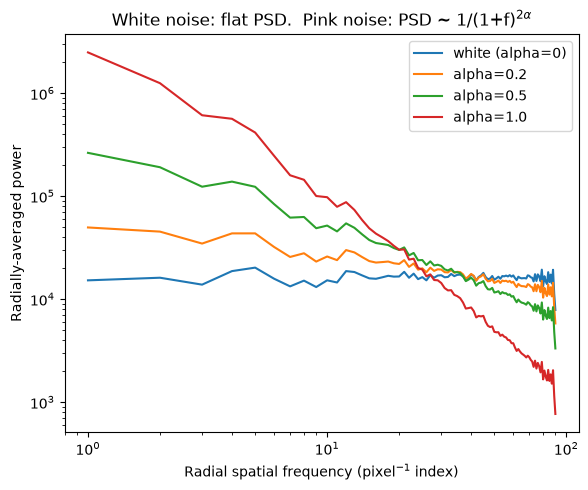

In [7]:
def radial_average_psd(tensor_chw):
    """Channel-averaged radial PSD profile, binned by integer pixel radius from DC."""
    profiles = []
    for c in range(tensor_chw.shape[0]):
        img = tensor_chw[c].numpy()
        h, w = img.shape
        psd2d = np.abs(np.fft.fftshift(np.fft.fft2(img))) ** 2
        cy, cx = h // 2, w // 2
        yy, xx = np.indices((h, w))
        r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2).astype(int)
        radial_sum = np.bincount(r.ravel(), weights=psd2d.ravel())
        radial_count = np.bincount(r.ravel())
        profiles.append(radial_sum / np.maximum(radial_count, 1))
    return np.mean(profiles, axis=0)


fig, ax = plt.subplots(figsize=(6, 5))
for alpha in ALPHAS:
    psd = radial_average_psd(noise_by_alpha[alpha][0])
    freq_index = np.arange(1, len(psd))  # skip DC (index 0) on the log-log plot
    ax.loglog(freq_index, psd[1:], label="white (alpha=0)" if alpha == 0.0 else f"alpha={alpha}")
ax.set_xlabel("Radial spatial frequency (pixel$^{-1}$ index)")
ax.set_ylabel("Radially-averaged power")
ax.set_title("White noise: flat PSD.  Pink noise: PSD ~ 1/(1+f)$^{2\\alpha}$")
ax.legend()
fig.tight_layout()
fig.savefig("white_vs_pink_psd_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Save the presentation figure

Combined spatial (top row) + spectrum (bottom row) figure, saved next to this notebook
for reuse in slides, alongside the PSD curve saved above.

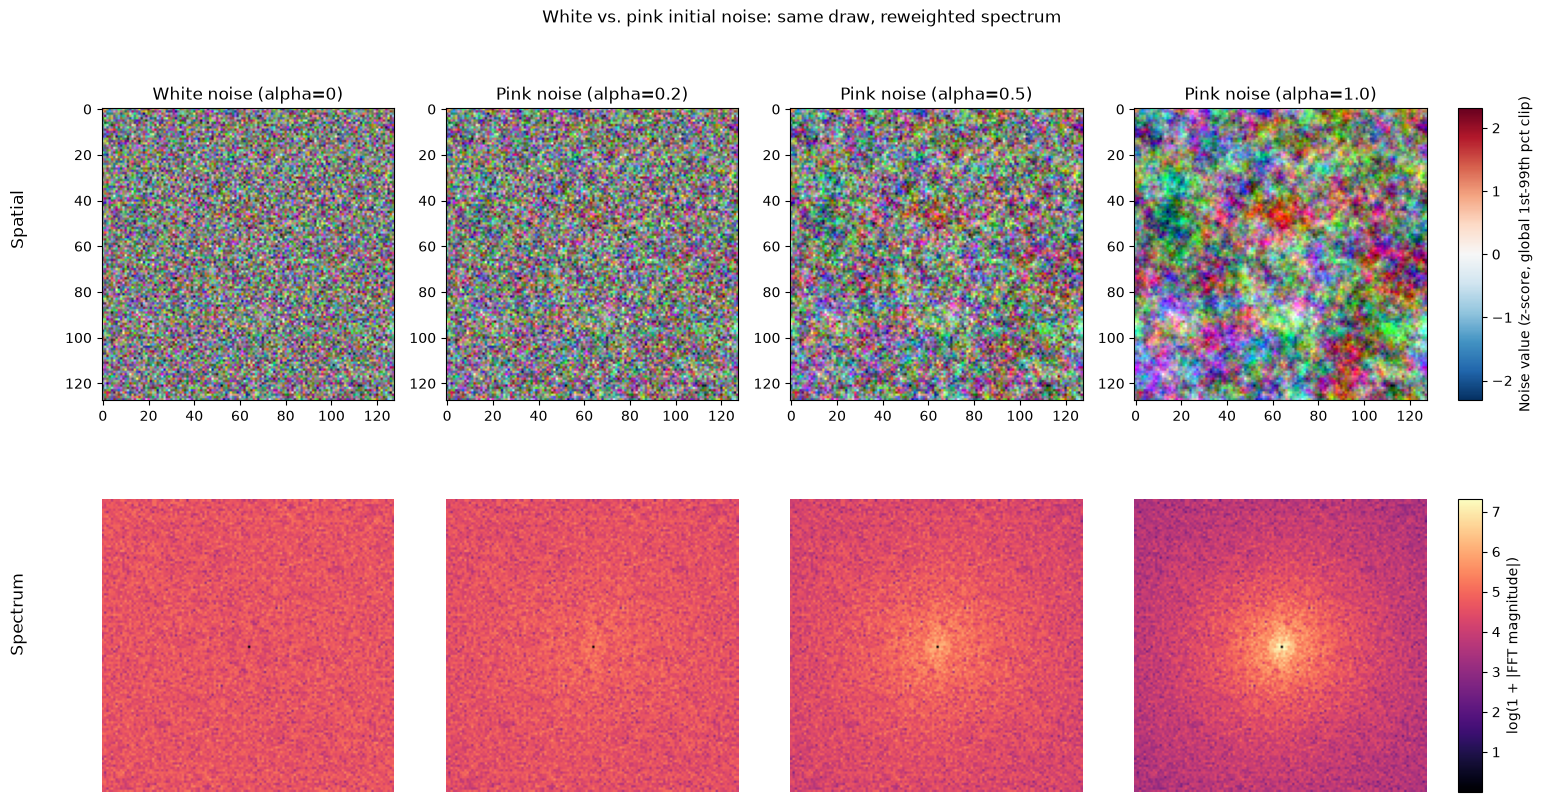

Saved: white_vs_pink_spatial_spectrum.png


In [16]:
spectra = [log_magnitude_spectrum(noise_by_alpha[alpha][0]) for alpha in ALPHAS]
spec_vmin = min(s.min() for s in spectra)
spec_vmax = max(s.max() for s in spectra)

fig, axes = plt.subplots(2, len(ALPHAS), figsize=(4 * len(ALPHAS), 8.4))
spec_im = None
for col, (alpha, spectrum) in enumerate(zip(ALPHAS, spectra)):
    label = "White noise (alpha=0)" if alpha == 0.0 else f"Pink noise (alpha={alpha})"
    axes[0, col].imshow(to_rgb_display(noise_by_alpha[alpha][0], raw_lo, raw_hi))
    axes[0, col].set_title(label)
    axes[0, col].set_xticks(range(0, W + 1, 20))
    axes[0, col].set_yticks(range(0, H + 1, 20))

    spec_im = axes[1, col].imshow(spectrum, cmap="magma", vmin=spec_vmin, vmax=spec_vmax)
    axes[1, col].axis("off")

fig.text(0.005, 0.75, "Spatial", va="center", rotation="vertical", fontsize=12)
fig.text(0.005, 0.28, "Spectrum", va="center", rotation="vertical", fontsize=12)
fig.suptitle("White vs. pink initial noise: same draw, reweighted spectrum", y=1.0)
fig.tight_layout(rect=[0.03, 0, 0.9, 1])

# Fixed-position colorbar axes (rather than auto-shrinking ax=... colorbars) so both
# rows keep equal image width and each colorbar stays aligned with its own row.
top_pos = axes[0, -1].get_position()
bottom_pos = axes[1, -1].get_position()
cax_top = fig.add_axes([0.91, top_pos.y0, 0.015, top_pos.height])
cax_bottom = fig.add_axes([0.91, bottom_pos.y0, 0.015, bottom_pos.height])
# Diverging colormap centered at 0, since the noise is zero-mean/unit-std z-scored.
spatial_norm = mcolors.TwoSlopeNorm(vmin=raw_lo, vcenter=0.0, vmax=raw_hi)
spatial_sm = plt.cm.ScalarMappable(norm=spatial_norm, cmap="RdBu_r")
fig.colorbar(spatial_sm, cax=cax_top, label="Noise value (z-score, global 1st-99th pct clip)")
fig.colorbar(spec_im, cax=cax_bottom, label="log(1 + |FFT magnitude|)")

out_path = "white_vs_pink_spatial_spectrum.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")